# Model Fitting Tutorial

This notebook provides a comprehensive guide to fitting epidemic models to data using the `epimodels.fitting` module.

## Overview

The fitting module provides:
1. **Dataset**: Register and validate observed data with state variable mappings
2. **Loss Functions**: Multiple options (SSE, Poisson, Negative Binomial, etc.)
3. **Optimizers**: Scipy, JAX, and Nevergrad backends
4. **ModelFitter**: Main API for fitting models to data

We'll cover:
- Generating synthetic data for testing
- Basic fitting workflow
- Data registration and validation
- Comparing loss functions and optimizers
- Advanced features: fixed parameters, initial condition fitting, profile likelihood

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from epimodels.continuous.models import SIR, SEIR, SIRS
from epimodels.fitting import (
    Dataset,
    DataSeries,
    ParameterSpec,
    ModelFitter,
    FittingResult,
    fit_model,
    SumOfSquaredErrors,
    WeightedSSE,
    PoissonLikelihood,
    NegativeBinomialLikelihood,
    NormalLikelihood,
    HuberLoss,
    ScipyOptimizer,
    MultiStartOptimizer,
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Generating Synthetic Data

Before fitting, we need data. Let's generate synthetic data from an SIR model with known parameters, then add realistic noise.

In [4]:
# True parameters
TRUE_BETA = 0.4
TRUE_GAMMA = 0.1
TOTAL_POPULATION = 10000
INITIAL_INFECTED = 50

# Generate ground truth data
ground_truth_model = SIR()
ground_truth_model(
    inits=[TOTAL_POPULATION - INITIAL_INFECTED, INITIAL_INFECTED, 0],
    trange=[0, 100],
    totpop=TOTAL_POPULATION,
    params={'beta': TRUE_BETA, 'gamma': TRUE_GAMMA},
)

# Extract time series
true_times = ground_truth_model.traces['time']
true_I = ground_truth_model.traces['I']
true_R = ground_truth_model.traces['R']

print(f"Ground truth parameters: beta={TRUE_BETA}, gamma={TRUE_GAMMA}")
print(f"R0 = {TRUE_BETA / TRUE_GAMMA:.1f}")
print(f"Time points: {len(true_times)}")

Ground truth parameters: beta=0.4, gamma=0.1
R0 = 4.0
Time points: 19


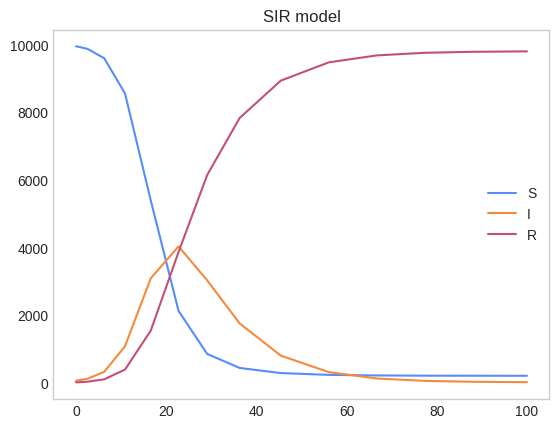

In [5]:
ground_truth_model.plot_traces()

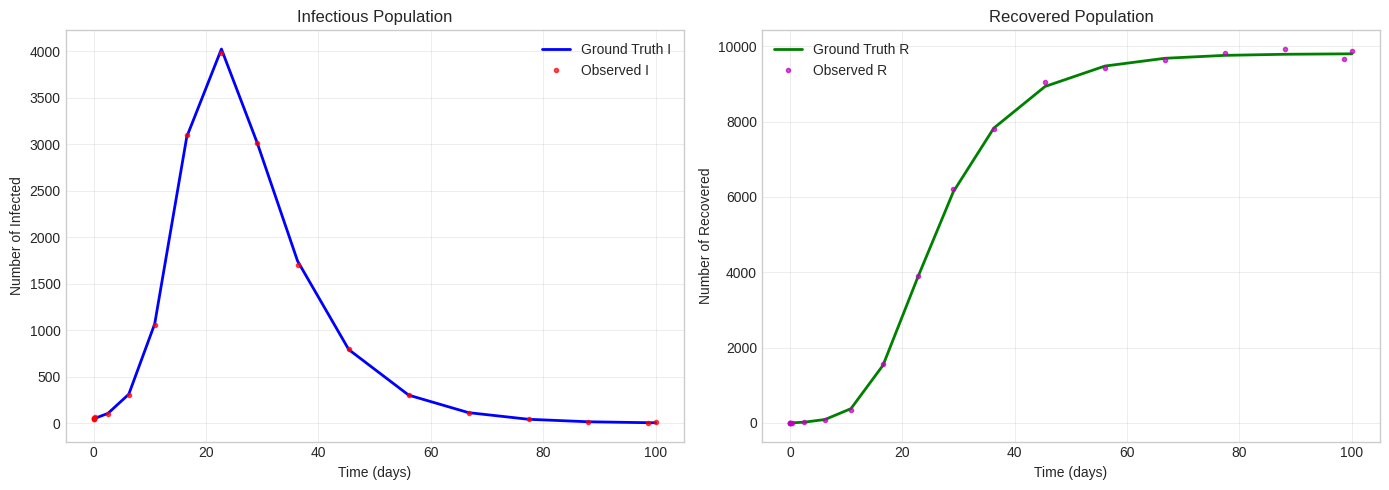

In [6]:
# Add realistic noise to simulate observations
# Using Poisson noise (appropriate for count data)
observed_I = np.random.poisson(lam=true_I).astype(float)
observed_R = np.random.poisson(lam=true_R).astype(float)

# Ensure non-negative
observed_I = np.maximum(observed_I, 0)
observed_R = np.maximum(observed_R, 0)

# Plot ground truth vs observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_times, true_I, 'b-', label='Ground Truth I', linewidth=2)
axes[0].plot(true_times, observed_I, 'ro', label='Observed I', markersize=3, alpha=0.7)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Number of Infected')
axes[0].set_title('Infectious Population')
axes[0].legend()

axes[1].plot(true_times, true_R, 'g-', label='Ground Truth R', linewidth=2)
axes[1].plot(true_times, observed_R, 'mo', label='Observed R', markersize=3, alpha=0.7)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Number of Recovered')
axes[1].set_title('Recovered Population')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Basic Fitting Workflow

The basic workflow consists of:
1. Create a `Dataset` and register observed data
2. Define `ParameterSpec` for parameters to fit
3. Create a `ModelFitter` with model, data, and specifications
4. Call `fit()` and analyze results

### 3.1 Register Data with Dataset

In [7]:
# Create a fresh model for fitting
model = SIR()

# Create dataset and register observed data
dataset = Dataset(model)

# Register the 'I' compartment data
dataset.register(
    name='infected',
    values=observed_I,
    times=true_times,
    state_variable='I',
    time_unit='days',
)

# Validate the dataset
validation_result = dataset.validate(total_population=TOTAL_POPULATION)
print(f"Dataset valid: {validation_result.is_valid}")
print(f"Time range: {dataset.time_range}")
print(dataset)

Dataset valid: True
Time range: (0.0, 100.0)
Dataset(n_series=1, variables=['I'], time_range=(0.0, 100.0))


### 3.2 Define Parameters to Fit

In [8]:
# Define parameter specifications
param_specs = [
    ParameterSpec(
        name='beta',
        bounds=(0.1, 1.0),
        initial=0.5,  # Initial guess
    ),
    ParameterSpec(
        name='gamma',
        bounds=(0.01, 0.5),
        initial=0.2,  # Initial guess
    ),
]

print("Parameters to fit:")
for spec in param_specs:
    print(f"  {spec.name}: bounds={spec.bounds}, initial={spec.initial}")

Parameters to fit:
  beta: bounds=(0.1, 1.0), initial=0.5
  gamma: bounds=(0.01, 0.5), initial=0.2


### 3.3 Create Fitter and Fit

In [9]:
# Create the fitter
fitter = ModelFitter(
    model=model,
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=TOTAL_POPULATION,
    optimizer=ScipyOptimizer(method='L-BFGS-B', max_iterations=200),
)

# Perform the fit
result = fitter.fit()

# Display results
print("\n" + "="*50)
print("FITTING RESULTS")
print("="*50)
print(f"Convergence: {result.convergence}")
print(f"Number of evaluations: {result.n_evaluations}")
print(f"Final loss: {result.best_loss:.2f}")
print("\nFitted parameters:")
for param, value in result.best_params.items():
    true_val = TRUE_BETA if param == 'beta' else TRUE_GAMMA
    error = abs(value - true_val) / true_val * 100
    print(f"  {param}: {value:.4f} (true: {true_val}, error: {error:.1f}%)")


FITTING RESULTS
Convergence: True
Number of evaluations: 60
Final loss: 2860.33

Fitted parameters:
  beta: 0.4067 (true: 0.4, error: 1.7%)
  gamma: 0.1008 (true: 0.1, error: 0.8%)


### 3.4 Visualize Fit Results

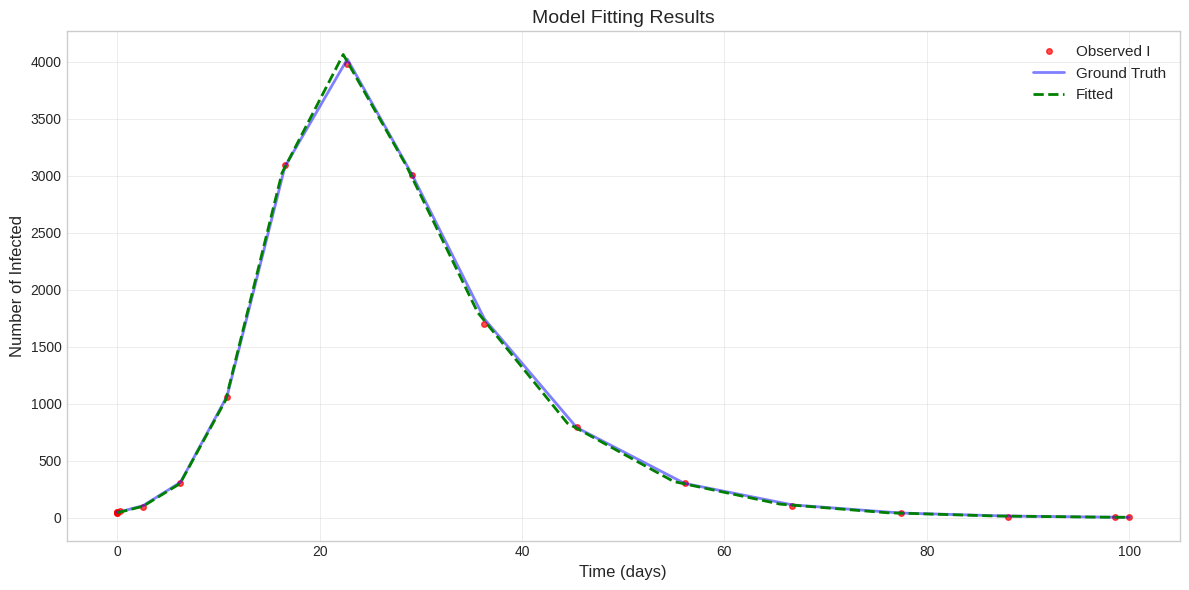

In [10]:
# Plot observed vs fitted
fitted_model = result.fitted_model

fig, ax = plt.subplots(figsize=(12, 6))

# Observed data
ax.plot(true_times, observed_I, 'ro', label='Observed I', markersize=4, alpha=0.7)

# Ground truth
ax.plot(true_times, true_I, 'b-', label='Ground Truth', linewidth=2, alpha=0.5)

# Fitted model
if fitted_model is not None and fitted_model.traces:
    ax.plot(fitted_model.traces['time'], fitted_model.traces['I'], 
            'g--', label='Fitted', linewidth=2)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Number of Infected', fontsize=12)
ax.set_title('Model Fitting Results', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Data Registration and Validation

The `Dataset` class provides robust data handling with validation.

### 4.1 Registering Multiple Data Series

In [11]:
# Register both I and R compartments
model2 = SIR()
dataset2 = Dataset(model2)

dataset2.register(
    name='infected',
    values=observed_I,
    times=true_times,
    state_variable='I',
).register(
    name='recovered',
    values=observed_R,
    times=true_times,
    state_variable='R',
)

print(f"Registered series: {list(dataset2.series.keys())}")
print(f"State variables mapped: {list(set(s.state_variable for s in dataset2.series.values()))}")

Registered series: ['infected', 'recovered']
State variables mapped: ['I', 'R']


### 4.2 Validation Errors

In [12]:
# Example: Invalid state variable
from epimodels.fitting import DataValidationError

model_test = SIR()
dataset_test = Dataset(model_test)

dataset_test.register(
    name='invalid',
    values=observed_I,
    times=true_times,
    state_variable='X',  # 'X' doesn't exist in SIR model
)

validation = dataset_test.validate()
print(f"Valid: {validation.is_valid}")
print(f"Errors: {validation.errors}")

Valid: False
Errors: ["Series 'invalid': state variable 'X' not found in model. Available: ['I', 'S', 'R']", "Data mapped to non-existent variables: ['X']"]


### 4.3 Time Unit Handling

In [13]:
# Data with different time units
model3 = SIR()
dataset3 = Dataset(model3)

# Register with weeks instead of days
weeks = true_times / 7.0

dataset3.register(
    name='infected_weekly',
    values=observed_I,
    times=weeks,
    state_variable='I',
    time_unit='weeks',
)

print(f"Dataset time unit: {dataset3.time_unit}")
print(f"Series time unit: {dataset3.series['infected_weekly'].time_unit}")
print(f"Time range: {dataset3.time_range}")

Dataset time unit: weeks
Series time unit: weeks
Time range: (0.0, 14.285714285714286)


### 4.4 DataFrame Integration

In [14]:
import pandas as pd

# Create a DataFrame with observations
df = pd.DataFrame({
    'day': true_times,
    'cases': observed_I,
    'recoveries': observed_R,
})

print("Sample data:")
display(df.head(10))

# Register from DataFrame
model_df = SIR()
dataset_df = Dataset(model_df)

dataset_df.register_from_dataframe(
    df=df,
    time_column='day',
    mapping={'cases': 'I', 'recoveries': 'R'},
    time_unit='days',
)

print(f"\nRegistered from DataFrame: {list(dataset_df.series.keys())}")

Sample data:


,day,cases,recoveries
0,0.000000,47.0,0.0
1,0.000283,55.0,0.0
2,0.003111,42.0,0.0
3,0.031395,53.0,0.0
4,0.314235,63.0,1.0
5,2.552370,96.0,24.0
6,6.256865,302.0,84.0
7,10.862630,1062.0,354.0
8,16.573157,3099.0,1564.0
9,22.737625,3986.0,3898.0



Registered from DataFrame: ['cases', 'recoveries']


## 5. Loss Functions

Different loss functions are appropriate for different data types and noise models.

### 5.1 Available Loss Functions

In [15]:
loss_functions = {
    'SSE': SumOfSquaredErrors(),
    'Poisson': PoissonLikelihood(),
    'NegBinom': NegativeBinomialLikelihood(dispersion=5.0),
    'Normal': NormalLikelihood(),
    'Huber': HuberLoss(delta=10.0),
}

print("Available loss functions:")
for name, lf in loss_functions.items():
    print(f"  - {name}: {lf.__class__.__name__}")

Available loss functions:
  - SSE: SumOfSquaredErrors
  - Poisson: PoissonLikelihood
  - NegBinom: NegativeBinomialLikelihood
  - Normal: NormalLikelihood
  - Huber: HuberLoss


### 5.2 Comparing Loss Functions

In [16]:
# Fit with different loss functions
results_comparison = {}

for name, loss_fn in loss_functions.items():
    print(f"Fitting with {name}...")
    
    fitter_comp = ModelFitter(
        model=SIR(),
        dataset=dataset,  # Using single-series dataset from earlier
        parameters_to_fit=param_specs,
        total_population=TOTAL_POPULATION,
        loss_fn=loss_fn,
        optimizer=ScipyOptimizer(method='L-BFGS-B', max_iterations=100),
    )
    
    result = fitter_comp.fit()
    results_comparison[name] = result

Fitting with SSE...
Fitting with Poisson...
Fitting with NegBinom...
Fitting with Normal...
Fitting with Huber...


In [17]:
# Compare results
print("\n" + "="*70)
print("LOSS FUNCTION COMPARISON")
print("="*70)
print(f"{'Loss Function':<15} {'beta':>10} {'gamma':>10} {'R0':>10} {'Loss':>12}")
print("-"*70)
print(f"{'TRUE VALUES':<15} {TRUE_BETA:>10.4f} {TRUE_GAMMA:>10.4f} {TRUE_BETA/TRUE_GAMMA:>10.2f} {'-':>12}")
print("-"*70)

for name, result in results_comparison.items():
    beta = result.best_params['beta']
    gamma = result.best_params['gamma']
    r0 = beta / gamma
    print(f"{name:<15} {beta:>10.4f} {gamma:>10.4f} {r0:>10.2f} {result.best_loss:>12.2f}")


LOSS FUNCTION COMPARISON
Loss Function         beta      gamma         R0         Loss
----------------------------------------------------------------------
TRUE VALUES         0.4000     0.1000       4.00            -
----------------------------------------------------------------------
SSE                 0.4067     0.1008       4.03      2860.33
Poisson             0.4057     0.1008       4.03       143.37
NegBinom            0.3994     0.1007       3.97       201.01
Normal              0.4067     0.1008       4.03        74.61
Huber               0.4056     0.1007       4.03      1068.47


### 5.3 When to Use Each Loss Function

| Loss Function | Best For | Assumptions |
|--------------|----------|-------------|
| **SSE** | General purpose | Gaussian errors |
| **Poisson** | Count data | Mean = Variance |
| **Negative Binomial** | Overdispersed counts | Variance > Mean |
| **Normal** | Continuous measurements | Known or estimated σ |
| **Huber** | Data with outliers | Robust to outliers |

## 6. Optimizers

The module supports multiple optimization backends.

### 6.1 Scipy Methods

In [18]:
# Compare scipy optimization methods
scipy_methods = ['L-BFGS-B', 'Nelder-Mead', 'Powell', 'differential_evolution']
optimizer_results = {}

for method in scipy_methods:
    print(f"Testing {method}...")
    
    optimizer = ScipyOptimizer(method=method, max_iterations=100)
    
    fitter_opt = ModelFitter(
        model=SIR(),
        dataset=dataset,
        parameters_to_fit=param_specs,
        total_population=TOTAL_POPULATION,
        optimizer=optimizer,
    )
    
    result = fitter_opt.fit()
    optimizer_results[method] = result

Testing L-BFGS-B...
Testing Nelder-Mead...
Testing Powell...
Testing differential_evolution...


In [19]:
# Compare optimizer performance
print("\n" + "="*80)
print("OPTIMIZER COMPARISON")
print("="*80)
print(f"{'Method':<25} {'beta':>10} {'gamma':>10} {'Evals':>8} {'Converged':>10}")
print("-"*80)

for method, result in optimizer_results.items():
    beta = result.best_params['beta']
    gamma = result.best_params['gamma']
    print(f"{method:<25} {beta:>10.4f} {gamma:>10.4f} {result.n_evaluations:>8} {str(result.convergence):>10}")


OPTIMIZER COMPARISON
Method                          beta      gamma    Evals  Converged
--------------------------------------------------------------------------------
L-BFGS-B                      0.4067     0.1008       60       True
Nelder-Mead                   0.4067     0.1008       60       True
Powell                        0.4067     0.1008       60       True
differential_evolution        0.4067     0.1008     1164       True


### 6.2 Multi-Start Optimization

For robust results, especially with local minima, use multi-start optimization.

In [20]:
# Multi-start optimization
base_optimizer = ScipyOptimizer(method='L-BFGS-B', max_iterations=50)
multi_start = MultiStartOptimizer(
    base_optimizer=base_optimizer,
    n_starts=5,
    sampling_method='latin_hypercube',
    seed=42,
)

fitter_ms = ModelFitter(
    model=SIR(),
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=TOTAL_POPULATION,
    optimizer=multi_start,
)

result_ms = fitter_ms.fit()

print(f"Multi-start optimization results:")
print(f"  beta: {result_ms.best_params['beta']:.4f}")
print(f"  gamma: {result_ms.best_params['gamma']:.4f}")
print(f"  Total evaluations: {result_ms.n_evaluations}")

Multi-start optimization results:
  beta: 0.4067
  gamma: 0.1008
  Total evaluations: 477


## 7. Advanced Features

### 7.1 Fixed Parameters

Sometimes we know some parameters and only want to fit others.

In [21]:
# Fix gamma and only fit beta
fitter_fixed = ModelFitter(
    model=SIR(),
    dataset=dataset,
    parameters_to_fit=[
        ParameterSpec(name='beta', bounds=(0.1, 1.0), initial=0.5),
    ],
    total_population=TOTAL_POPULATION,
    fixed_params={'gamma': TRUE_GAMMA},  # Fix gamma at true value
)

result_fixed = fitter_fixed.fit()

print("Fitting with fixed gamma:")
print(f"  Fitted beta: {result_fixed.best_params['beta']:.4f} (true: {TRUE_BETA})")
print(f"  Fixed gamma: {TRUE_GAMMA}")

Fitting with fixed gamma:
  Fitted beta: 0.4064 (true: 0.4)
  Fixed gamma: 0.1


### 7.2 Log-Scale Parameter Transformation

For parameters spanning orders of magnitude, log-scale transformation can improve optimization.

In [23]:
# =noisy_I,# Parameters with log-scale transformation
param_specs_log = [
    ParameterSpec(
        name='beta',
        bounds=(0.01, 1.0),
        initial=0.3,
        log_scale=True,  # Search in log space
    ),
    ParameterSpec(
        name='gamma',
        bounds=(0.01, 0.5),
        initial=0.1,
        log_scale=True,  # Search in log space
    ),
]

print("Log-scale parameter specs:")
for spec in param_specs_log:
    print(f"  {spec.name}: bounds={spec.bounds}, log_scale={spec.log_scale}")

Log-scale parameter specs:
  beta: bounds=(0.01, 1.0), log_scale=True
  gamma: bounds=(0.01, 0.5), log_scale=True


### 7.3 Profile Likelihood for Confidence Intervals

In [24]:
# Compute profile likelihood for beta
profile_result = fitter.profile_likelihood(
    param_name='beta',
    n_points=20,
    threshold=3.84,  # Chi-squared 95% CI for 1 df
)

print("Profile likelihood analysis for beta:")
print(f"  Minimum loss: {profile_result['min_loss']:.2f}")
print(f"  95% CI threshold: {profile_result['threshold_loss']:.2f}")
print(f"  Confidence interval: {profile_result['confidence_interval']}")

Profile likelihood analysis for beta:
  Minimum loss: 283984.09
  95% CI threshold: 283986.01
  Confidence interval: (np.float64(0.43157894736842106), np.float64(0.43157894736842106))


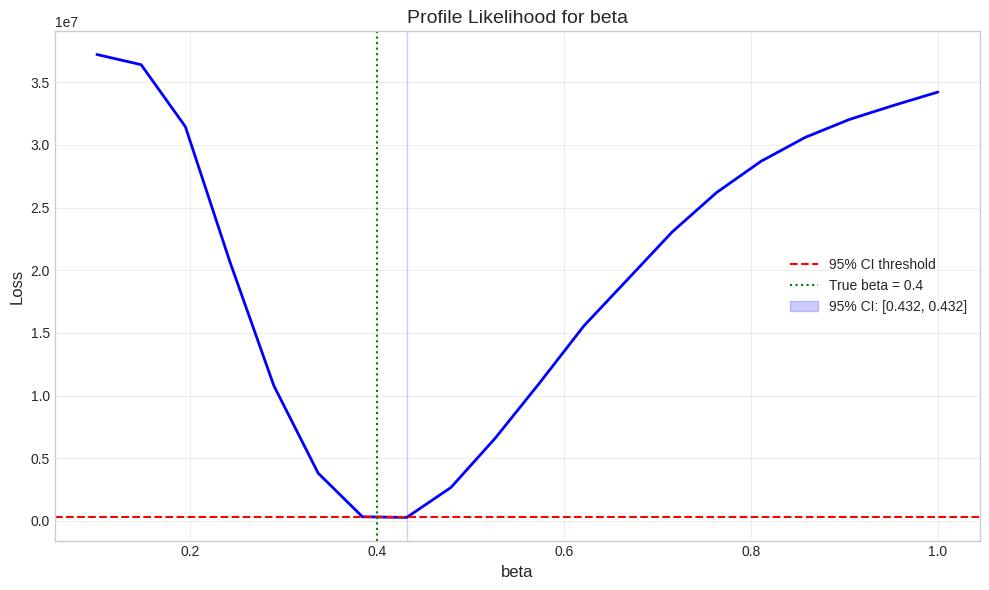

In [25]:
# Plot profile likelihood
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(profile_result['values'], profile_result['losses'], 'b-', linewidth=2)
ax.axhline(y=profile_result['threshold_loss'], color='r', linestyle='--', 
           label=f"95% CI threshold")
ax.axvline(x=TRUE_BETA, color='g', linestyle=':', label=f"True beta = {TRUE_BETA}")

# Shade CI region
ci = profile_result['confidence_interval']
if ci[0] is not None and ci[1] is not None:
    ax.axvspan(ci[0], ci[1], alpha=0.2, color='blue', label=f"95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")

ax.set_xlabel('beta', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Profile Likelihood for beta', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 7.4 Fitting Initial Conditions

By default, initial conditions are estimated from the first data point and kept fixed. You can also fit initial conditions alongside model parameters using `fit_initial_conditions=True`.

For more control, use `InitialConditionSpec` to specify:
- `bounds`: Search range for the initial value
- `initial`: Starting value for optimization
- `fixed`: If `True`, the IC is held fixed during fitting

This allows you to fix some initial conditions (e.g., S[0] = N - I[0] - R[0]) while fitting others.

In [26]:
# Example: Fit initial conditions for I and R, but fix S based on total population
from epimodels.fitting import InitialConditionSpec

# Create dataset with both I and R observations
model_ic = SIR()
dataset_ic = Dataset(model_ic)
dataset_ic.register(
    name='infected',
    values=observed_I,
    times=true_times,
    state_variable='I',
).register(
    name='recovered',
    values=observed_R,
    times=true_times,
    state_variable='R',
)

# Specify IC fitting: fix S[0], fit I[0] and R[0]
# S[0] will be computed as: TOTAL_POPULATION - I[0] - R[0]
ic_specs = [
    InitialConditionSpec(
        state_variable='S',
        bounds=(TOTAL_POPULATION - 100, TOTAL_POPULATION),
        initial=TOTAL_POPULATION - INITIAL_INFECTED,
        fixed=False,  # Fixed - will be computed from other ICs
    ),
    InitialConditionSpec(
        state_variable='I',
        bounds=(1, 500),
        initial=INITIAL_INFECTED,
        fixed=True,  # Will be fitted
    ),
    InitialConditionSpec(
        state_variable='R',
        bounds=(0, 100),
        initial=0,
        fixed=False,  # Will be fitted
    ),
]

# Create fitter with IC fitting enabled
fitter_ic = ModelFitter(
    model=model_ic,
    dataset=dataset_ic,
    parameters_to_fit=[
        ParameterSpec(name='beta', bounds=(0.1, 1.0), initial=0.5),
        ParameterSpec(name='gamma', bounds=(0.01, 0.5), initial=0.2),
    ],
    total_population=TOTAL_POPULATION,
    fit_initial_conditions=True,
    initial_condition_specs=ic_specs,
)

# Fit the model
result_ic = fitter_ic.fit()

print("Fitting with initial conditions:")
print(f"  Fitted beta: {result_ic.best_params['beta']:.4f} (true: {TRUE_BETA})")
print(f"  Fitted gamma: {result_ic.best_params['gamma']:.4f} (true: {TRUE_GAMMA})")
print(f"  Fitted I[0]: {result_ic.best_initial_conditions[1]:.1f} (true: {INITIAL_INFECTED})")
print(f"  Fitted R[0]: {result_ic.best_initial_conditions[2]:.1f} (true: 0)")
print(f"  Fixed S[0]: {result_ic.best_initial_conditions[0]:.1f}")

/home/fccoelho/Documentos/Software_projects/epimodels/epimodels/fitting/base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (10150.0) exceeds total population (10000)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
/home/fccoelho/Documentos/Software_projects/epimodels/epimodels/fitting/base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (10149.99999999) exceeds total population (10000)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
/home/fccoelho/Documentos/Software_projects/epimodels/epimodels/fitting/base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (10037.678751579851) exceeds total population (10000)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
/home/fccoelho/Documentos/Software_projects/epimodels/epimodels/fitting/base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (10037.678751589852) exceeds total population (100

Fitting with initial conditions:
  Fitted beta: 0.4037 (true: 0.4)
  Fitted gamma: 0.0986 (true: 0.1)
  Fitted I[0]: 50.0 (true: 50)
  Fitted R[0]: 6.7 (true: 0)
  Fixed S[0]: 9953.3


## 8. Practical Example: Handling Noisy and Missing Data

Real-world data often has noise, outliers, and missing observations.

### 8.1 Generate Realistic Noisy Data

In [25]:
# Generate data with more realistic noise
np.random.seed(123)

# Ground truth with more time points
ground_truth = SIR()
ground_truth(
    inits=[TOTAL_POPULATION - INITIAL_INFECTED, INITIAL_INFECTED, 0],
    trange=[0, 80],
    totpop=TOTAL_POPULATION,
    params={'beta': 0.35, 'gamma': 0.12},
)

# Create denser time points for sampling
full_times = np.linspace(0, 80, 100)
from scipy.interpolate import interp1d
interp_I = interp1d(ground_truth.traces['time'], ground_truth.traces['I'], kind='linear', fill_value='extrapolate')
full_I = interp_I(full_times)

# Sample every 5 days (realistic observation frequency)
sample_indices = np.arange(0, len(full_times), 5)
sample_times = full_times[sample_indices]
sample_I = full_I[sample_indices]

# Add noise with some outliers
noisy_I = sample_I + np.random.normal(0, 50, size=len(sample_I))

# Add a few outliers (indices within range)
n_samples = len(sample_times)
outlier_indices = [min(5, n_samples-1), min(10, n_samples-1), min(15, n_samples-1)]
outlier_indices = [i for i in outlier_indices if i < n_samples]
noisy_I[outlier_indices] += np.random.uniform(200, 400, size=len(outlier_indices))

# Ensure non-negative
noisy_I = np.maximum(noisy_I, 0)

print(f"Sampled {len(sample_times)} time points from {len(full_times)} total")
print(f"Added outliers at indices: {outlier_indices}")

Sampled 20 time points from 100 total
Added outliers at indices: [5, 10, 15]


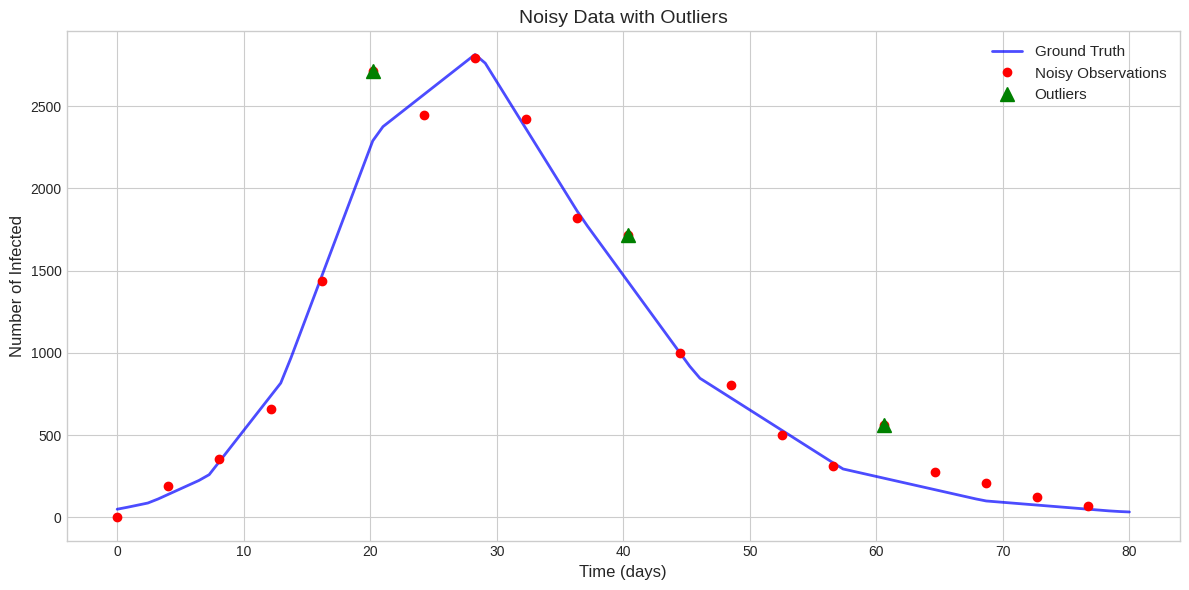

In [26]:
# Plot the noisy data
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(full_times, full_I, 
        'b-', label='Ground Truth', linewidth=2, alpha=0.7)
ax.plot(sample_times, noisy_I, 'ro', label='Noisy Observations', markersize=6)
if outlier_indices:
    ax.plot(sample_times[outlier_indices], noisy_I[outlier_indices], 
            'g^', label='Outliers', markersize=10)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Number of Infected', fontsize=12)
ax.set_title('Noisy Data with Outliers', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8.2 Compare SSE vs Huber Loss on Noisy Data

In [29]:
# Create dataset with noisy data
noisy_dataset = Dataset(SIR())
noisy_dataset.register(
    name='noisy_infected',
    values=noisy_I,
    times=sample_times,
    state_variable='I',
)

# Parameters to fit
noisy_params = [
    ParameterSpec(name='beta', bounds=(0.1, 0.8), initial=0.4),
    ParameterSpec(name='gamma', bounds=(0.05, 0.3), initial=0.15),
]

# Fit with SSE
fitter_sse = ModelFitter(
    model=SIR(),
    dataset=noisy_dataset,
    parameters_to_fit=noisy_params,
    total_population=TOTAL_POPULATION,
    loss_fn=SumOfSquaredErrors(),
)
result_sse = fitter_sse.fit()

# Fit with Huber loss (robust to outliers)
fitter_huber = ModelFitter(
    model=SIR(),
    dataset=noisy_dataset,
    parameters_to_fit=noisy_params,
    total_population=TOTAL_POPULATION,
    loss_fn=HuberLoss(delta=50.0),
)
result_huber = fitter_huber.fit()

print("Comparison on noisy data with outliers:")
print(f"  True:     beta=0.35, gamma=0.12")
print(f"  SSE:      beta={result_sse.best_params['beta']:.3f}, gamma={result_sse.best_params['gamma']:.3f}")
print(f"  Huber:    beta={result_huber.best_params['beta']:.3f}, gamma={result_huber.best_params['gamma']:.3f}")

Comparison on noisy data with outliers:
  True:     beta=0.35, gamma=0.12
  SSE:      beta=0.400, gamma=0.150
  Huber:    beta=0.400, gamma=0.150


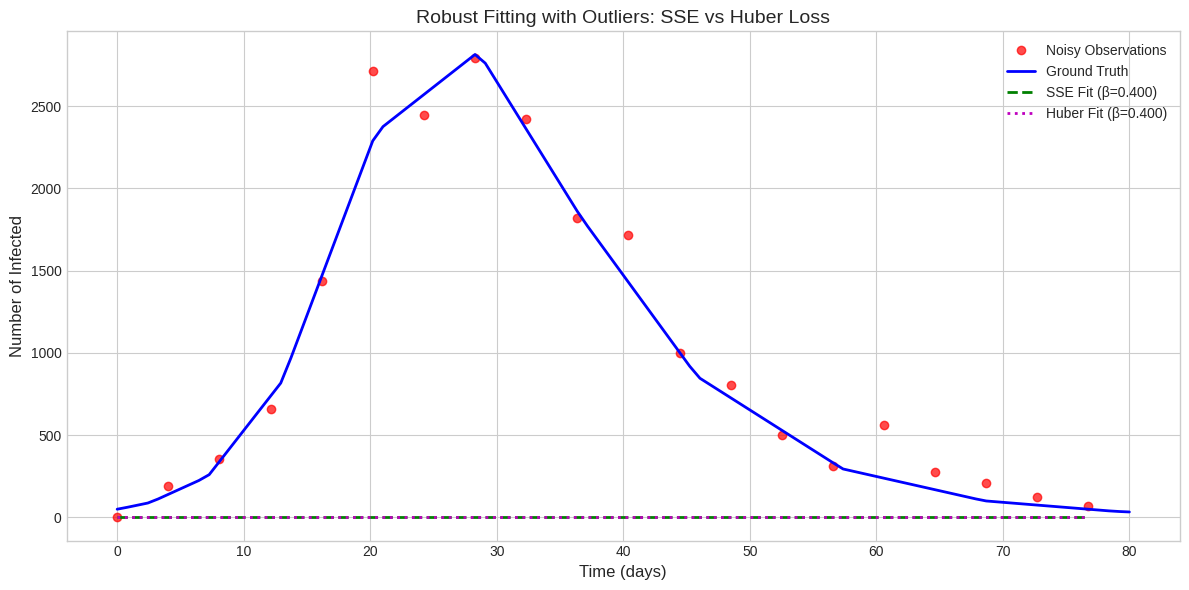

In [30]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Observations
ax.plot(sample_times, noisy_I, 'ro', label='Noisy Observations', markersize=6, alpha=0.7)

# Ground truth
ax.plot(full_times, full_I, 
        'b-', label='Ground Truth', linewidth=2)

# SSE fit
if result_sse.fitted_model and result_sse.fitted_model.traces:
    ax.plot(result_sse.fitted_model.traces['time'], result_sse.fitted_model.traces['I'],
            'g--', label=f"SSE Fit (β={result_sse.best_params['beta']:.3f})", linewidth=2)

# Huber fit
if result_huber.fitted_model and result_huber.fitted_model.traces:
    ax.plot(result_huber.fitted_model.traces['time'], result_huber.fitted_model.traces['I'],
            'm:', label=f"Huber Fit (β={result_huber.best_params['beta']:.3f})", linewidth=2)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Number of Infected', fontsize=12)
ax.set_title('Robust Fitting with Outliers: SSE vs Huber Loss', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9. Convenience Function

For quick fitting, use the `fit_model` convenience function.

In [31]:
# Quick fit with convenience function
result_quick = fit_model(
    model=SIR(),
    data={'I': observed_I},
    times=true_times,
    params_to_fit={'beta': (0.1, 1.0), 'gamma': (0.01, 0.5)},
    total_population=TOTAL_POPULATION,
    variable_mapping={'I': 'I'},
)

print("Quick fit results:")
print(f"  beta: {result_quick.best_params['beta']:.4f}")
print(f"  gamma: {result_quick.best_params['gamma']:.4f}")
print(f"  R0: {result_quick.best_params['beta'] / result_quick.best_params['gamma']:.2f}")

Quick fit results:
  beta: 0.4067
  gamma: 0.1008
  R0: 4.03


## 10. Summary and Best Practices

### Key Takeaways

1. **Data Registration**: Always validate your dataset before fitting
2. **Loss Functions**: Choose based on your data type:
   - SSE for general use
   - Poisson/NegBinom for count data
   - Huber for data with outliers

3. **Optimizers**:
   - L-BFGS-B for fast, local optimization (good initial guess)
   - Differential evolution for global optimization
   - Multi-start for robustness

4. **Parameter Scaling**: Use `log_scale=True` for parameters spanning orders of magnitude

5. **Validation**: Use profile likelihood for confidence intervals

### Common Pitfalls

- **Poor initial guesses**: Can lead to local minima
- **Wrong loss function**: SSE on count data can over-weight high values
- **Too narrow bounds**: May exclude true parameter values
- **Ignoring validation**: Data issues should be caught early

In [27]:
# Clean up
print("\n" + "="*60)
print("Tutorial complete!")
print("="*60)


Tutorial complete!
